# Project: Parameter Estimation for a Probability Distribution
# Description:
In this project, you will implement the maximum likelihood estimation (MLE) algorithm to estimate the parameters of a selected probability distribution based on a given dataset.
# Task:
1. Choose a probability distribution (e.g., normal distribution, exponential distribution) and specify its probability density function (PDF) or probability mass function (PMF).
2. Generate a synthetic dataset based on the chosen distribution with known parameters.
3. Implement the MLE algorithm using Python to estimate the parameters of the distribution from the synthetic dataset.
4. Compare the estimated parameters with the known true parameters and calculate the estimation error.
5. Repeat the process for multiple iterations with different dataset sizes to analyze the performance of the MLE algorithm with varying sample sizes.


## 1. Choose Distribution

We will use:

*   **Normal Distribution**
*   **Exponential Distribution**

**Normal:**

$f(x) = \frac{1}{\sigma \sqrt{2\pi}} e^{ -\frac{(x-\mu)^2}{2\sigma^2} }$

**Exponential:**

$f(x) = \lambda e^{-\lambda x}$

## 2. Generate Synthetic Data

In [2]:
import numpy as np

# True parameters (updated values)
mu_true = 5
sigma_true = 2
lambda_true = 0.8

# Generate data
data_normal = np.random.normal(mu_true, sigma_true, 500)
data_exp = np.random.exponential(1/lambda_true, 500)

print("Sample Normal Data:", data_normal[:5])
print("Sample Exponential Data:", data_exp[:5])

Sample Normal Data: [4.88805799 9.08533289 5.1396628  2.77796924 7.05380066]
Sample Exponential Data: [0.04820195 0.35083801 0.60137248 5.42046636 1.40228295]


## 3. MLE Implementation

In [3]:
import numpy as np

# Normal MLE
def mle_normal(data):
    mu = np.mean(data)
    sigma = np.std(data)
    return mu, sigma

# Exponential MLE
def mle_exponential(data):
    lam = 1 / np.mean(data)
    return lam

# Apply
mu_est, sigma_est = mle_normal(data_normal)
lambda_est = mle_exponential(data_exp)

print("Normal Estimate:", mu_est, sigma_est)
print("Exponential Estimate:", lambda_est)

Normal Estimate: 5.019852969147032 2.0997719420077896
Exponential Estimate: 0.8124565515455806


## 4. Compare + Error Calculation

In [4]:
print("---- Normal Distribution ----")
print("True mu:", mu_true, "Estimated:", round(mu_est, 3))
print("True sigma:", sigma_true, "Estimated:", round(sigma_est, 3))

print("Error mu:", abs(mu_est - mu_true))
print("Error sigma:", abs(sigma_est - sigma_true))

print("\n---- Exponential Distribution ----")
print("True lambda:", lambda_true, "Estimated:", round(lambda_est, 3))
print("Error lambda:", abs(lambda_est - lambda_true))

---- Normal Distribution ----
True mu: 5 Estimated: 5.02
True sigma: 2 Estimated: 2.1
Error mu: 0.019852969147032162
Error sigma: 0.0997719420077896

---- Exponential Distribution ----
True lambda: 0.8 Estimated: 0.812
Error lambda: 0.012456551545580563


## 5. Performance vs Sample Size

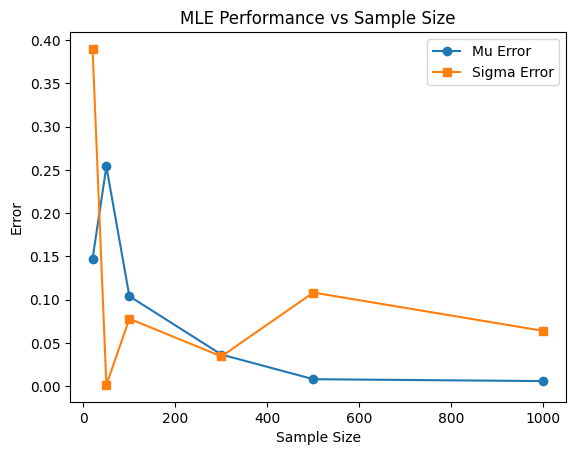

In [5]:
import matplotlib.pyplot as plt

sizes = [20, 50, 100, 300, 500, 1000]

mu_errors = []
sigma_errors = []

for n in sizes:
    data = np.random.normal(mu_true, sigma_true, n)
    mu_est = np.mean(data)
    sigma_est = np.std(data)

    mu_errors.append(abs(mu_est - mu_true))
    sigma_errors.append(abs(sigma_est - sigma_true))

# Plot
plt.plot(sizes, mu_errors, marker='o', label="Mu Error")
plt.plot(sizes, sigma_errors, marker='s', label="Sigma Error")

plt.xlabel("Sample Size")
plt.ylabel("Error")
plt.title("MLE Performance vs Sample Size")
plt.legend()
plt.show()

## 6. Visualization

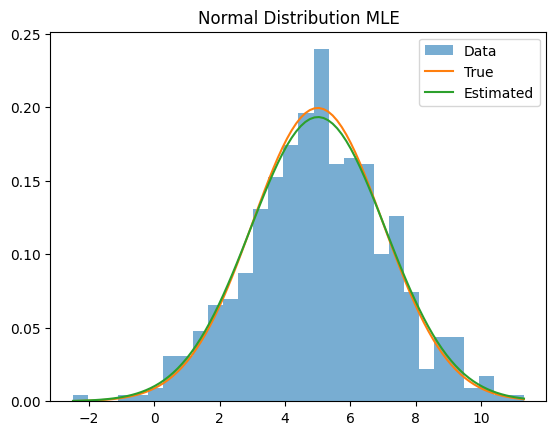

In [6]:
import matplotlib.pyplot as plt
from scipy.stats import norm

x = np.linspace(min(data_normal), max(data_normal), 100)

plt.hist(data_normal, bins=30, density=True, alpha=0.6, label="Data")
plt.plot(x, norm.pdf(x, mu_true, sigma_true), label="True")
plt.plot(x, norm.pdf(x, mu_est, sigma_est), label="Estimated")

plt.title("Normal Distribution MLE")
plt.legend()
plt.show()